In [2]:
## 0. Rebuild More Realistic Ad Campaign Data


In [3]:
import numpy as np
import pandas as pd

np.random.seed(42)

platforms = ["Ocean Engine", "Tencent Ads", "Kwai Ads"]
channels = ["Feed Ads", "Search Ads", "Short Video", "Splash Ads"]
creative_types = ["Image & Text", "Short Video", "Live Clip"]
audiences = ["Returning Users", "New Users", "Students", "Female 18-24", "Male 25-34", "Tier-1 White Collar"]

n_campaigns = 60
campaign_names = [f"Campaign_{i:03d}" for i in range(1, n_campaigns + 1)]

plan_tiers = np.random.choice(
    ["High Performer", "Stable", "Click-Heavy", "Low Efficiency"],
    size=n_campaigns,
    p=[0.2, 0.45, 0.2, 0.15]
)

campaign_profiles = []

for i, campaign in enumerate(campaign_names):
    tier = plan_tiers[i]

    platform = np.random.choice(platforms, p=[0.4, 0.35, 0.25])
    channel = np.random.choice(channels, p=[0.45, 0.2, 0.25, 0.1])
    creative = np.random.choice(creative_types, p=[0.3, 0.5, 0.2])
    audience = np.random.choice(audiences)

    if tier == "High Performer":
        base_ctr = np.random.uniform(0.05, 0.085)
        base_cvr = np.random.uniform(0.11, 0.18)
        base_cpc = np.random.uniform(3.8, 5.5)
        avg_daily_impressions = np.random.randint(18000, 45000)
        revenue_per_conversion = np.random.uniform(80, 130)

    elif tier == "Stable":
        base_ctr = np.random.uniform(0.035, 0.06)
        base_cvr = np.random.uniform(0.08, 0.12)
        base_cpc = np.random.uniform(4.5, 6.5)
        avg_daily_impressions = np.random.randint(12000, 32000)
        revenue_per_conversion = np.random.uniform(60, 100)

    elif tier == "Click-Heavy":
        base_ctr = np.random.uniform(0.06, 0.09)
        base_cvr = np.random.uniform(0.04, 0.075)
        base_cpc = np.random.uniform(4.8, 7.5)
        avg_daily_impressions = np.random.randint(15000, 38000)
        revenue_per_conversion = np.random.uniform(45, 80)

    else:  # Low Efficiency
        base_ctr = np.random.uniform(0.025, 0.05)
        base_cvr = np.random.uniform(0.03, 0.065)
        base_cpc = np.random.uniform(5.5, 8.5)
        avg_daily_impressions = np.random.randint(10000, 28000)
        revenue_per_conversion = np.random.uniform(35, 70)

    campaign_profiles.append({
        "campaign_name": campaign,
        "platform_en": platform,
        "channel_en": channel,
        "creative_type_en": creative,
        "target_audience_en": audience,
        "plan_tier": tier,
        "base_ctr": round(base_ctr, 4),
        "base_cvr": round(base_cvr, 4),
        "base_cpc": round(base_cpc, 4),
        "avg_daily_impressions": avg_daily_impressions,
        "revenue_per_conversion": round(revenue_per_conversion, 2)
    })

campaign_profile_df = pd.DataFrame(campaign_profiles)
campaign_profile_df.head()

,campaign_name,platform_en,channel_en,creative_type_en,target_audience_en,plan_tier,base_ctr,base_cvr,base_cpc,avg_daily_impressions,revenue_per_conversion
0,Campaign_001,Ocean Engine,Feed Ads,Live Clip,New Users,Stable,0.0591,0.1043,5.0520,17276,92.09
1,Campaign_002,Ocean Engine,Splash Ads,Short Video,Female 18-24,Low Efficiency,0.0323,0.0305,6.0965,10391,60.52
2,Campaign_003,Kwai Ads,Feed Ads,Short Video,Returning Users,Click-Heavy,0.0874,0.0698,6.0135,34488,47.22
3,Campaign_004,Ocean Engine,Feed Ads,Short Video,Tier-1 White Collar,Stable,0.0572,0.0989,4.7392,25773,93.96
4,Campaign_005,Tencent Ads,Feed Ads,Image & Text,Students,High Performer,0.0683,0.1399,3.8432,35868,90.09


In [4]:
campaign_profile_df["plan_tier"].value_counts()

plan_tier
Stable            24
High Performer    18
Low Efficiency    10
Click-Heavy        8
Name: count, dtype: int64

In [5]:
campaign_profile_df.groupby(["platform_en","plan_tier"]).size().unstack(fill_value=0)

plan_tier,Click-Heavy,High Performer,Low Efficiency,Stable
platform_en,,,,
Kwai Ads,1,4,3,5
Ocean Engine,6,6,5,13
Tencent Ads,1,8,2,6


In [6]:
dates = pd.date_range("2025-01-01", "2025-03-31", freq="D")

records = []

platform_ctr_factor = {
    "Ocean Engine": 1.05,
    "Tencent Ads": 1.12,
    "Kwai Ads": 0.95
}

platform_cvr_factor = {
    "Ocean Engine": 1.08,
    "Tencent Ads": 0.92,
    "Kwai Ads": 1.00
}

creative_ctr_factor = {
    "Image & Text": 0.95,
    "Short Video": 1.08,
    "Live Clip": 1.02
}

creative_cvr_factor = {
    "Image & Text": 0.92,
    "Short Video": 1.10,
    "Live Clip": 1.04
}

audience_cvr_factor = {
    "Returning Users": 1.28,
    "New Users": 0.88,
    "Students": 0.82,
    "Female 18-24": 1.02,
    "Male 25-34": 0.97,
    "Tier-1 White Collar": 1.15
}

for _, row in campaign_profile_df.iterrows():
    for d in dates:
        weekday_factor = 1.08 if d.weekday() in [5, 6] else 1.00

        impressions = max(
            1000,
            int(np.random.lognormal(
                mean=np.log(row["avg_daily_impressions"] * weekday_factor),
                sigma=0.25
            ))
        )

        ctr = (
            row["base_ctr"]
            * platform_ctr_factor[row["platform_en"]]
            * creative_ctr_factor[row["creative_type_en"]]
            * np.random.uniform(0.88, 1.12)
        )
        ctr = min(max(ctr, 0.01), 0.12)

        clicks = int(impressions * ctr)

        cvr = (
            row["base_cvr"]
            * platform_cvr_factor[row["platform_en"]]
            * creative_cvr_factor[row["creative_type_en"]]
            * audience_cvr_factor[row["target_audience_en"]]
            * np.random.uniform(0.85, 1.15)
        )
        cvr = min(max(cvr, 0.01), 0.25)

        conversions = int(clicks * cvr)

        cpc = row["base_cpc"] * np.random.uniform(0.9, 1.12)
        cost = round(clicks * cpc, 2)

        revenue = round(conversions * row["revenue_per_conversion"] * np.random.uniform(0.92, 1.08), 2)

        # 注入少量异常日：高花费低产出
        is_abnormal_day = np.random.rand() < 0.03
        if is_abnormal_day:
            cost = round(cost * np.random.uniform(1.2, 1.45), 2)
            revenue = round(revenue * np.random.uniform(0.6, 0.85), 2)

        records.append({
            "date": d,
            "platform_en": row["platform_en"],
            "channel_en": row["channel_en"],
            "campaign_name": row["campaign_name"],
            "ad_group": f"AdGroup_{np.random.randint(1, 100):03d}",
            "creative_type_en": row["creative_type_en"],
            "target_audience_en": row["target_audience_en"],
            "plan_tier": row["plan_tier"],
            "impressions": impressions,
            "clicks": clicks,
            "conversions": conversions,
            "cost": cost,
            "revenue": revenue
        })

df_clean = pd.DataFrame(records)
df_clean.head()

,date,platform_en,channel_en,campaign_name,ad_group,creative_type_en,target_audience_en,plan_tier,impressions,clicks,conversions,cost,revenue
0,2025-01-01,Ocean Engine,Feed Ads,Campaign_001,AdGroup_030,Live Clip,New Users,Stable,21224,1211,133,6243.01,12151.77
1,2025-01-02,Ocean Engine,Feed Ads,Campaign_001,AdGroup_074,Live Clip,New Users,Stable,28859,1880,214,10532.01,18594.43
2,2025-01-03,Ocean Engine,Feed Ads,Campaign_001,AdGroup_023,Live Clip,New Users,Stable,17837,1087,102,5642.67,9155.06
3,2025-01-04,Ocean Engine,Feed Ads,Campaign_001,AdGroup_056,Live Clip,New Users,Stable,16542,953,87,4480.15,8192.42
4,2025-01-05,Ocean Engine,Feed Ads,Campaign_001,AdGroup_082,Live Clip,New Users,Stable,23940,1520,178,7928.04,15667.75


In [7]:
df_clean["ctr"] = np.where(df_clean["impressions"] > 0, df_clean["clicks"] / df_clean["impressions"], 0).round(4)
df_clean["cvr"] = np.where(df_clean["clicks"] > 0, df_clean["conversions"] / df_clean["clicks"], 0).round(4)
df_clean["cpc"] = np.where(df_clean["clicks"] > 0, df_clean["cost"] / df_clean["clicks"], 0).round(4)
df_clean["cpa"] = np.where(df_clean["conversions"] > 0, df_clean["cost"] / df_clean["conversions"], 0).round(4)
df_clean["roi"] = np.where(df_clean["cost"] > 0, df_clean["revenue"] / df_clean["cost"], 0).round(4)

df_clean.shape

(5400, 18)

In [8]:
df_clean.groupby("platform_en")[["impressions", "clicks", "conversions", "cost", "revenue", "ctr", "cvr", "cpa", "roi"]].mean().round(4)

,impressions,clicks,conversions,cost,revenue,ctr,cvr,cpa,roi
platform_en,,,,,,,,,
Kwai Ads,26578.9333,1596.5709,210.7043,8550.4061,18471.4310,0.0550,0.1123,69.4119,1.8841
Ocean Engine,24004.1904,1556.1356,182.1619,8601.3594,16623.0835,0.0602,0.1075,75.5674,1.6868
Tencent Ads,29013.7255,1846.0039,211.6745,9076.1571,21267.4195,0.0620,0.1043,64.3512,2.1580


In [9]:
df_clean.groupby("plan_tier")[["ctr", "cvr", "cpc", "cpa", "roi"]].mean().round(4)

,ctr,cvr,cpc,cpa,roi
plan_tier,,,,,
Click-Heavy,0.0817,0.0678,5.8032,89.4997,0.6934
High Performer,0.0745,0.1556,4.6491,31.9593,3.5898
Low Efficiency,0.0360,0.0471,7.5703,171.3663,0.3194
Stable,0.0509,0.1101,5.4704,52.4341,1.6011


In [10]:
df_clean["plan_tier"].value_counts()

plan_tier
Stable            2160
High Performer    1620
Low Efficiency     900
Click-Heavy        720
Name: count, dtype: int64

In [11]:
df_clean.to_csv("../data/clean/ad_data_clean_v2.csv", index=False)

## 3. 数据检查与清洗

In [12]:
# 3.1 Basic Data Inspection

print("Shape:", df_clean.shape)
print("\nColumns:")
print(df_clean.columns.tolist())

print("\nData Types:")
print(df_clean.dtypes)

print("\nMissing Values:")
print(df_clean.isnull().sum())

print("\nDuplicate Rows:", df_clean.duplicated().sum())

df_clean.head()

Shape: (5400, 18)

Columns:
['date', 'platform_en', 'channel_en', 'campaign_name', 'ad_group', 'creative_type_en', 'target_audience_en', 'plan_tier', 'impressions', 'clicks', 'conversions', 'cost', 'revenue', 'ctr', 'cvr', 'cpc', 'cpa', 'roi']

Data Types:
date                  datetime64[us]
platform_en                      str
channel_en                       str
campaign_name                    str
ad_group                         str
creative_type_en                 str
target_audience_en               str
plan_tier                        str
impressions                    int64
clicks                         int64
conversions                    int64
cost                         float64
revenue                      float64
ctr                          float64
cvr                          float64
cpc                          float64
cpa                          float64
roi                          float64
dtype: object

Missing Values:
date                  0
platform_en           

,date,platform_en,channel_en,campaign_name,ad_group,creative_type_en,target_audience_en,plan_tier,impressions,clicks,conversions,cost,revenue,ctr,cvr,cpc,cpa,roi
0,2025-01-01,Ocean Engine,Feed Ads,Campaign_001,AdGroup_030,Live Clip,New Users,Stable,21224,1211,133,6243.01,12151.77,0.0571,0.1098,5.1553,46.9399,1.9465
1,2025-01-02,Ocean Engine,Feed Ads,Campaign_001,AdGroup_074,Live Clip,New Users,Stable,28859,1880,214,10532.01,18594.43,0.0651,0.1138,5.6021,49.2150,1.7655
2,2025-01-03,Ocean Engine,Feed Ads,Campaign_001,AdGroup_023,Live Clip,New Users,Stable,17837,1087,102,5642.67,9155.06,0.0609,0.0938,5.1910,55.3203,1.6225
3,2025-01-04,Ocean Engine,Feed Ads,Campaign_001,AdGroup_056,Live Clip,New Users,Stable,16542,953,87,4480.15,8192.42,0.0576,0.0913,4.7011,51.4960,1.8286
4,2025-01-05,Ocean Engine,Feed Ads,Campaign_001,AdGroup_082,Live Clip,New Users,Stable,23940,1520,178,7928.04,15667.75,0.0635,0.1171,5.2158,44.5396,1.9762


In [13]:
# 3.2 Data Type Standardization

df_clean = df_clean.copy()

df_clean["date"] = pd.to_datetime(df_clean["date"])

numeric_cols = [
    "impressions", "clicks", "conversions",
    "cost", "revenue", "ctr", "cvr", "cpc", "cpa", "roi"
]

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

categorical_cols = [
    "platform_en", "channel_en", "campaign_name", "ad_group",
    "creative_type_en", "target_audience_en", "plan_tier"
]

for col in categorical_cols:
    df_clean[col] = df_clean[col].astype("string")

print("Data types standardized.")
df_clean.dtypes

Data types standardized.


date                  datetime64[us]
platform_en                   string
channel_en                    string
campaign_name                 string
ad_group                      string
creative_type_en              string
target_audience_en            string
plan_tier                     string
impressions                    int64
clicks                         int64
conversions                    int64
cost                         float64
revenue                      float64
ctr                          float64
cvr                          float64
cpc                          float64
cpa                          float64
roi                          float64
dtype: object

In [14]:
# 3.3 Missing Value Check and Handling

missing_summary = df_clean.isnull().sum().sort_values(ascending=False)
print("Missing values by column:")
print(missing_summary)

# 数值列缺失先查看
numeric_missing = df_clean[numeric_cols].isnull().sum()
print("\nNumeric missing values:")
print(numeric_missing)

# 如果有缺失，数值列先用 0 处理（当前模拟数据一般不会有）
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(0)

# 类别列缺失填 Unknown
df_clean[categorical_cols] = df_clean[categorical_cols].fillna("Unknown")

print("\nMissing values after handling:")
print(df_clean.isnull().sum().sum())

Missing values by column:
date                  0
platform_en           0
channel_en            0
campaign_name         0
ad_group              0
creative_type_en      0
target_audience_en    0
plan_tier             0
impressions           0
clicks                0
conversions           0
cost                  0
revenue               0
ctr                   0
cvr                   0
cpc                   0
cpa                   0
roi                   0
dtype: int64

Numeric missing values:
impressions    0
clicks         0
conversions    0
cost           0
revenue        0
ctr            0
cvr            0
cpc            0
cpa            0
roi            0
dtype: int64

Missing values after handling:
0


In [15]:
# 3.4 Duplicate Check

print("Rows before dedup:", len(df_clean))

df_clean = df_clean.drop_duplicates()

print("Rows after dedup:", len(df_clean))
print("Removed duplicates:", df_clean.duplicated().sum())

Rows before dedup: 5400
Rows after dedup: 5400
Removed duplicates: 0


In [16]:
# 3.5 Metric Sanity Check

print("Check impossible relationships:")

print("Clicks > Impressions:", (df_clean["clicks"] > df_clean["impressions"]).sum())
print("Conversions > Clicks:", (df_clean["conversions"] > df_clean["clicks"]).sum())
print("Negative Cost:", (df_clean["cost"] < 0).sum())
print("Negative Revenue:", (df_clean["revenue"] < 0).sum())
print("Negative CTR:", (df_clean["ctr"] < 0).sum())
print("Negative CVR:", (df_clean["cvr"] < 0).sum())
print("Negative CPC:", (df_clean["cpc"] < 0).sum())
print("Negative CPA:", (df_clean["cpa"] < 0).sum())
print("Negative ROI:", (df_clean["roi"] < 0).sum())

Check impossible relationships:
Clicks > Impressions: 0
Conversions > Clicks: 0
Negative Cost: 0
Negative Revenue: 0
Negative CTR: 0
Negative CVR: 0
Negative CPC: 0
Negative CPA: 0
Negative ROI: 0


In [17]:
# 3.6 Recalculate Core Metrics

df_clean["ctr"] = np.where(
    df_clean["impressions"] > 0,
    df_clean["clicks"] / df_clean["impressions"],
    0
).round(4)

df_clean["cvr"] = np.where(
    df_clean["clicks"] > 0,
    df_clean["conversions"] / df_clean["clicks"],
    0
).round(4)

df_clean["cpc"] = np.where(
    df_clean["clicks"] > 0,
    df_clean["cost"] / df_clean["clicks"],
    0
).round(4)

df_clean["cpa"] = np.where(
    df_clean["conversions"] > 0,
    df_clean["cost"] / df_clean["conversions"],
    0
).round(4)

df_clean["roi"] = np.where(
    df_clean["cost"] > 0,
    df_clean["revenue"] / df_clean["cost"],
    0
).round(4)

df_clean[["ctr", "cvr", "cpc", "cpa", "roi"]].describe().round(4)

,ctr,cvr,cpc,cpa,roi
count,5400.0000,5400.0000,5400.0000,5400.0000,5400.0000
mean,0.0596,0.1076,5.6183,71.0558,1.8630
std,0.0190,0.0488,1.2231,53.1681,1.4103
min,0.0226,0.0258,3.4535,17.2269,0.0837
25%,0.0457,0.0682,4.7334,35.9534,0.7406
50%,0.0579,0.1041,5.3817,50.6494,1.4978
75%,0.0737,0.1365,6.2477,83.9609,2.6482
max,0.1116,0.2394,11.7065,369.9247,7.3540


In [18]:
# 3.7 Final Check

print("Final Shape:", df_clean.shape)
print("\nFinal Missing Values:")
print(df_clean.isnull().sum())

df_clean.head()

Final Shape: (5400, 18)

Final Missing Values:
date                  0
platform_en           0
channel_en            0
campaign_name         0
ad_group              0
creative_type_en      0
target_audience_en    0
plan_tier             0
impressions           0
clicks                0
conversions           0
cost                  0
revenue               0
ctr                   0
cvr                   0
cpc                   0
cpa                   0
roi                   0
dtype: int64


,date,platform_en,channel_en,campaign_name,ad_group,creative_type_en,target_audience_en,plan_tier,impressions,clicks,conversions,cost,revenue,ctr,cvr,cpc,cpa,roi
0,2025-01-01,Ocean Engine,Feed Ads,Campaign_001,AdGroup_030,Live Clip,New Users,Stable,21224,1211,133,6243.01,12151.77,0.0571,0.1098,5.1553,46.9399,1.9465
1,2025-01-02,Ocean Engine,Feed Ads,Campaign_001,AdGroup_074,Live Clip,New Users,Stable,28859,1880,214,10532.01,18594.43,0.0651,0.1138,5.6021,49.2150,1.7655
2,2025-01-03,Ocean Engine,Feed Ads,Campaign_001,AdGroup_023,Live Clip,New Users,Stable,17837,1087,102,5642.67,9155.06,0.0609,0.0938,5.1910,55.3203,1.6225
3,2025-01-04,Ocean Engine,Feed Ads,Campaign_001,AdGroup_056,Live Clip,New Users,Stable,16542,953,87,4480.15,8192.42,0.0576,0.0913,4.7011,51.4960,1.8286
4,2025-01-05,Ocean Engine,Feed Ads,Campaign_001,AdGroup_082,Live Clip,New Users,Stable,23940,1520,178,7928.04,15667.75,0.0635,0.1171,5.2158,44.5396,1.9762


## 4. 平台投放效果分析

In [19]:
platform_summary = df_clean.groupby("platform_en").agg(
    impressions=("impressions", "sum"),
    clicks=("clicks", "sum"),
    conversions=("conversions", "sum"),
    cost=("cost", "sum"),
    revenue=("revenue", "sum")
).reset_index()

platform_summary["ctr"] = (platform_summary["clicks"] / platform_summary["impressions"]).round(4)
platform_summary["cvr"] = (platform_summary["conversions"] / platform_summary["clicks"]).round(4)
platform_summary["cpc"] = (platform_summary["cost"] / platform_summary["clicks"]).round(4)
platform_summary["cpa"] = (platform_summary["cost"] / platform_summary["conversions"]).round(4)
platform_summary["roi"] = (platform_summary["revenue"] / platform_summary["cost"]).round(4)

platform_summary

,platform_en,impressions,clicks,conversions,cost,revenue,ctr,cvr,cpc,cpa,roi
0,Kwai Ads,31097352,1867988,246524,10003975.10,21611574.30,0.0601,0.1320,5.3555,40.5801,2.1603
1,Ocean Engine,64811314,4201566,491837,23223670.34,44882325.47,0.0648,0.1171,5.5274,47.2182,1.9326
2,Tencent Ads,44391000,2824386,323862,13886520.38,32539151.87,0.0636,0.1147,4.9167,42.8779,2.3432


In [20]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.unicode_minus"] = False

In [21]:
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.sans-serif"] = ["Noto Sans CJK SC", "SimHei", "Microsoft YaHei", "Arial Unicode MS"]
matplotlib.rcParams["axes.unicode_minus"] = False

findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not foun

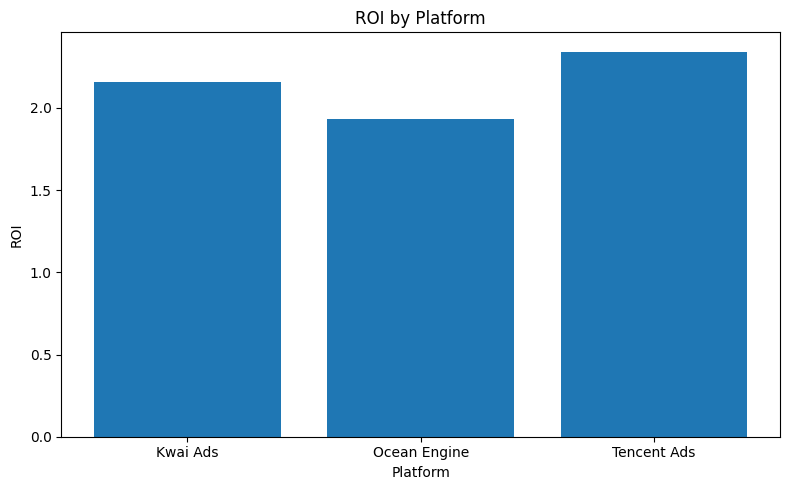

In [22]:
plt.figure(figsize=(8, 5))
plt.bar(platform_summary["platform_en"], platform_summary["roi"])
plt.title("ROI by Platform")
plt.xlabel("Platform")
plt.ylabel("ROI")
plt.tight_layout()
plt.savefig("../figures/platform_roi.png", dpi=300, bbox_inches="tight")
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not foun

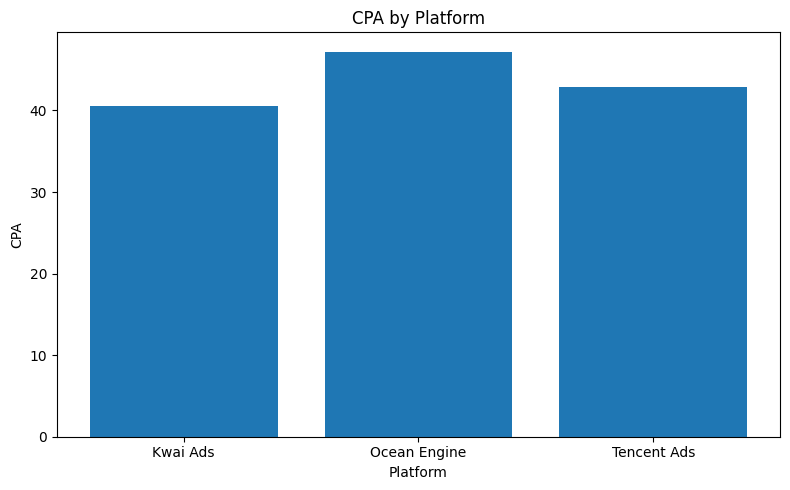

In [23]:
plt.figure(figsize=(8, 5))
plt.bar(platform_summary["platform_en"], platform_summary["cpa"])
plt.title("CPA by Platform")
plt.xlabel("Platform")
plt.ylabel("CPA")
plt.tight_layout()
plt.savefig("../figures/platform_cpa.png", dpi=300, bbox_inches="tight")
plt.show()

### 平台投放效果分析结论
从平台维度看，不同广告平台在流量规模、成本控制和收益表现上存在明显差异。

- 巨量引擎曝光规模最大，ROI 最高，CPA 最低，说明该平台在当前样本下兼具放量能力和转化效率；
- 腾讯广告 CTR 最高，说明点击吸引能力较强，但其 CPA 最高、ROI 最低，说明点击质量和转化效率相对偏弱；
- 磁力引擎整体表现居中，在成本与收益之间呈现相对平衡的状态。

这表明广告投放分析不能只关注曝光和点击规模，还需要结合 CPA、ROI 等指标综合评估平台投放效果。

## 5. 高消耗低转化广告计划识别

In [24]:
campaign_summary = df_clean.groupby("campaign_name").agg(
    impressions=("impressions", "sum"),
    clicks=("clicks", "sum"),
    conversions=("conversions", "sum"),
    cost=("cost", "sum"),
    revenue=("revenue", "sum")
).reset_index()

campaign_summary["ctr"] = campaign_summary["clicks"] / campaign_summary["impressions"]
campaign_summary["cvr"] = campaign_summary["conversions"] / campaign_summary["clicks"]
campaign_summary["cpc"] = campaign_summary["cost"] / campaign_summary["clicks"]
campaign_summary["cpa"] = campaign_summary["cost"] / campaign_summary["conversions"]
campaign_summary["roi"] = campaign_summary["revenue"] / campaign_summary["cost"]

cost_threshold = campaign_summary["cost"].quantile(0.75)
roi_threshold = campaign_summary["roi"].quantile(0.25)

problem_campaigns = campaign_summary[
    (campaign_summary["cost"] >= cost_threshold) &
    (campaign_summary["roi"] <= roi_threshold)
].copy().sort_values(by="cost", ascending=False)

problem_campaigns["campaign_label"] = (
    problem_campaigns["campaign_name"]
    .str.extract(r"(\d+)", expand=False)
    .apply(lambda x: f"Campaign_{int(x):03d}")
)

problem_campaigns_display = problem_campaigns[[
    "campaign_label", "impressions", "clicks", "conversions",
    "cost", "revenue", "ctr", "cvr", "cpc", "cpa", "roi"
]].head(10)

problem_campaigns_display

,campaign_label,impressions,clicks,conversions,cost,revenue,ctr,cvr,cpc,cpa,roi
12,Campaign_013,3364841,321559,21379,1713610.67,1086964.97,0.095564,0.066485,5.329071,80.153921,0.634313
38,Campaign_039,2505163,250337,11932,1519866.57,705301.44,0.099928,0.047664,6.071282,127.377352,0.464055
25,Campaign_026,3222242,233891,13126,1196356.60,814406.40,0.072586,0.056120,5.115018,91.144035,0.680739
35,Campaign_036,2039084,182616,13001,1189585.02,837753.50,0.089558,0.071193,6.514134,91.499502,0.704240


findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not foun

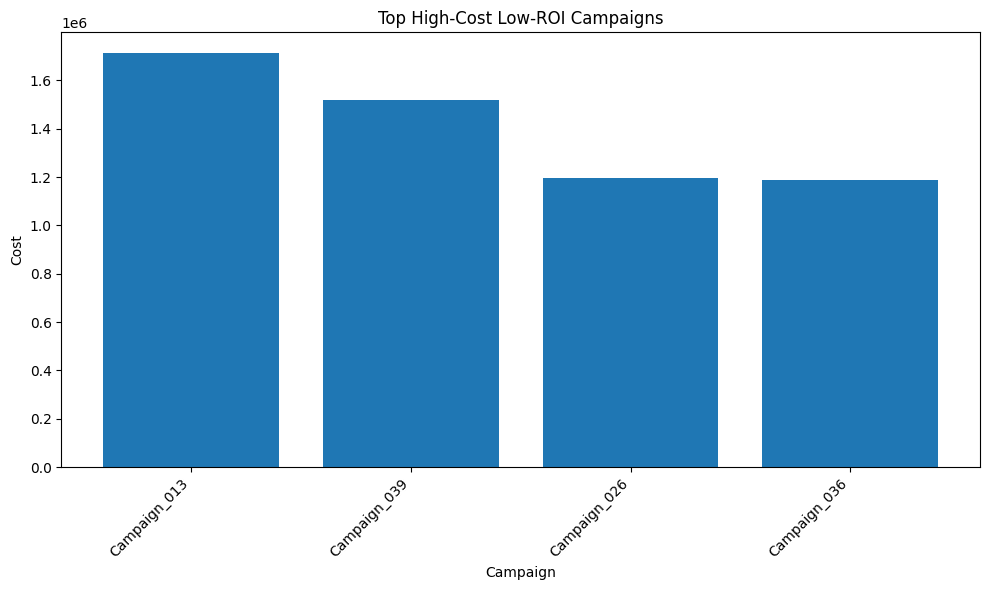

In [25]:


top_problem_campaigns = problem_campaigns.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_problem_campaigns["campaign_label"], top_problem_campaigns["cost"])
plt.title("Top High-Cost Low-ROI Campaigns")
plt.xlabel("Campaign")
plt.ylabel("Cost")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/high_cost_low_roi_campaigns.png", dpi=300, bbox_inches="tight")
plt.show()

### 高消耗低转化广告计划识别结论
基于广告计划维度的汇总结果，进一步以“高消耗且低 ROI”作为筛选标准，对问题广告计划进行识别。

分析结果表明，部分广告计划虽然消耗较高，但转化效率偏低、ROI 表现较差，属于典型的高消耗低转化计划。这类计划可能存在以下问题：

- 素材吸引力不足，导致点击后转化效率偏低；
- 人群定向不够精准，带来较高成本但未形成有效转化；
- 投放渠道或平台与目标人群匹配度较低；
- 预算分配不合理，导致低效计划持续消耗成本。

在实际投放中，这类广告计划应重点监控，并结合素材、人群和渠道维度进一步排查原因，作为预算调整和投放优化的重要依据。

## 6. 不同素材类型转化效果分析

In [26]:
creative_summary = df_clean.groupby("creative_type_en").agg(
    impressions=("impressions", "sum"),
    clicks=("clicks", "sum"),
    conversions=("conversions", "sum"),
    cost=("cost", "sum")
).reset_index()

creative_summary["ctr"] = (creative_summary["clicks"] / creative_summary["impressions"]).round(4)
creative_summary["cvr"] = (creative_summary["conversions"] / creative_summary["clicks"]).round(4)
creative_summary["cpa"] = (creative_summary["cost"] / creative_summary["conversions"]).round(4)

creative_summary

,creative_type_en,impressions,clicks,conversions,cost,ctr,cvr,cpa
0,Image & Text,34341142,2020951,216103,9866994.16,0.0588,0.1069,45.6588
1,Live Clip,30485600,2030931,292194,10571623.89,0.0666,0.1439,36.1802
2,Short Video,75472924,4842058,553926,26675547.77,0.0642,0.1144,48.1572


findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not foun

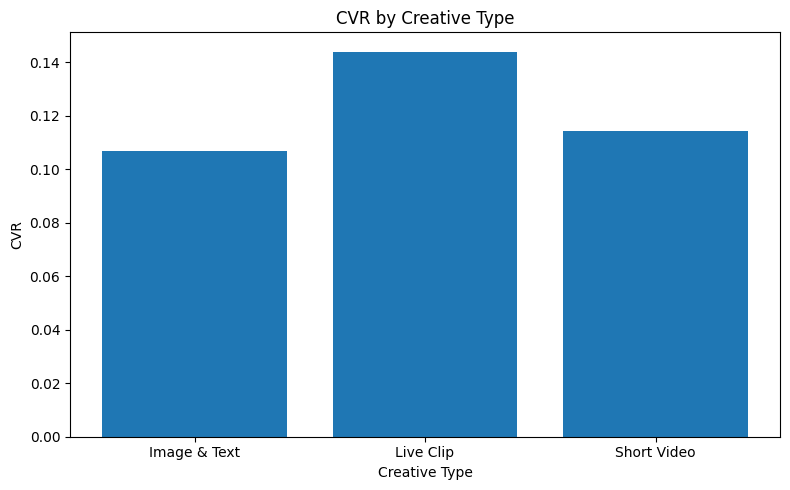

In [27]:
plt.figure(figsize=(8, 5))
plt.bar(creative_summary["creative_type_en"], creative_summary["cvr"])
plt.title("CVR by Creative Type")
plt.xlabel("Creative Type")
plt.ylabel("CVR")
plt.tight_layout()
plt.savefig("../figures/cvr_by_creative_type.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. 不同人群转化效果分析

In [28]:
audience_summary = df_clean.groupby("target_audience_en").agg(
    impressions=("impressions", "sum"),
    clicks=("clicks", "sum"),
    conversions=("conversions", "sum"),
    cost=("cost", "sum")
).reset_index()

audience_summary["ctr"] = (audience_summary["clicks"] / audience_summary["impressions"]).round(4)
audience_summary["cvr"] = (audience_summary["conversions"] / audience_summary["clicks"]).round(4)
audience_summary["cpa"] = (audience_summary["cost"] / audience_summary["conversions"]).round(4)

audience_summary

,target_audience_en,impressions,clicks,conversions,cost,ctr,cvr,cpa
0,Female 18-24,25675734,1692659,241126,8901937.86,0.0659,0.1425,36.9182
1,Male 25-34,20643717,1306891,115695,7165775.52,0.0633,0.0885,61.9368
2,New Users,24334918,1477191,138686,7648005.37,0.0607,0.0939,55.1462
3,Returning Users,31360453,2075345,329996,11233677.91,0.0662,0.1590,34.0419
4,Students,23625296,1532055,132929,7913663.92,0.0648,0.0868,59.5330
5,Tier-1 White Collar,14659548,809799,103791,4251105.24,0.0552,0.1282,40.9583


findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not foun

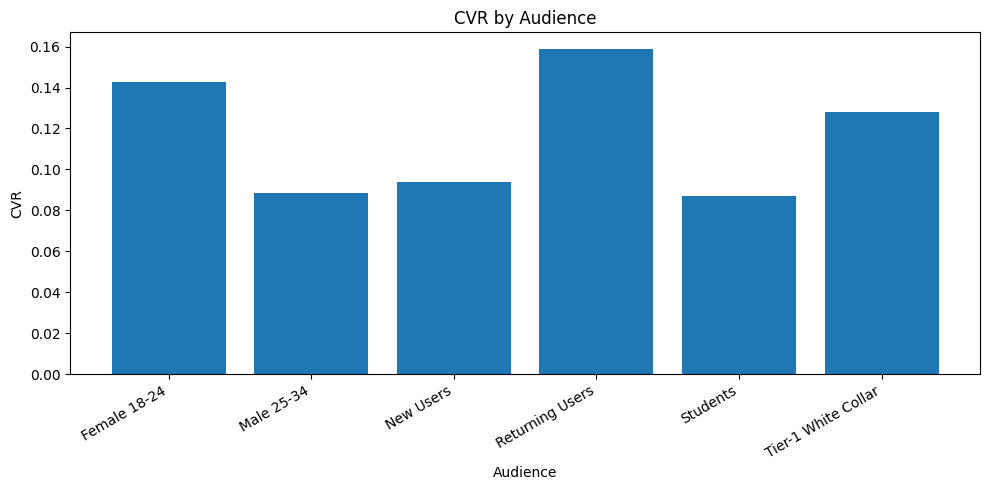

In [29]:
plt.figure(figsize=(10, 5))
plt.bar(audience_summary["target_audience_en"], audience_summary["cvr"])
plt.title("CVR by Audience")
plt.xlabel("Audience")
plt.ylabel("CVR")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../figures/cvr_by_audience.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. SQL 分析验证(DuckDB)

In [30]:
import duckdb

con = duckdb.connect()

# 直接把清洗后的 CSV 注册成表
con.execute("""
    CREATE OR REPLACE TABLE ad_data AS
    SELECT * FROM read_csv_auto('../data/clean/ad_data_clean.csv');
""")

con.execute("SELECT COUNT(*) AS row_count FROM ad_data").df()

con.execute("DESCRIBE ad_data").df()

,column_name,column_type,null,key,default,extra
0,date,DATE,YES,None,None,None
1,platform_en,VARCHAR,YES,None,None,None
2,channel_en,VARCHAR,YES,None,None,None
3,campaign_name,VARCHAR,YES,None,None,None
4,ad_group,VARCHAR,YES,None,None,None
5,creative_type_en,VARCHAR,YES,None,None,None
6,target_audience_en,VARCHAR,YES,None,None,None
7,plan_tier,VARCHAR,YES,None,None,None
8,impressions,BIGINT,YES,None,None,None
9,clicks,BIGINT,YES,None,None,None


### 8.1平台效果分析

In [31]:
platform_sql = """
SELECT
    platform_en AS platform,
    SUM(impressions) AS impressions,
    SUM(clicks) AS clicks,
    SUM(conversions) AS conversions,
    ROUND(SUM(cost), 2) AS cost,
    ROUND(SUM(revenue), 2) AS revenue,
    ROUND(SUM(clicks) * 1.0 / NULLIF(SUM(impressions), 0), 4) AS ctr,
    ROUND(SUM(conversions) * 1.0 / NULLIF(SUM(clicks), 0), 4) AS cvr,
    ROUND(SUM(cost) * 1.0 / NULLIF(SUM(clicks), 0), 4) AS cpc,
    ROUND(SUM(cost) * 1.0 / NULLIF(SUM(conversions), 0), 4) AS cpa,
    ROUND(SUM(revenue) * 1.0 / NULLIF(SUM(cost), 0), 4) AS roi
FROM ad_data
GROUP BY platform_en
ORDER BY roi DESC
"""

platform_sql_result = con.execute(platform_sql).df()
platform_sql_result

,platform,impressions,clicks,conversions,cost,revenue,ctr,cvr,cpc,cpa,roi
0,Tencent Ads,44391000.0,2824386.0,323862.0,13886520.38,32539151.87,0.0636,0.1147,4.9167,42.8779,2.3432
1,Kwai Ads,31097352.0,1867988.0,246524.0,10003975.10,21611574.30,0.0601,0.1320,5.3555,40.5801,2.1603
2,Ocean Engine,64811314.0,4201566.0,491837.0,23223670.34,44882325.47,0.0648,0.1171,5.5274,47.2182,1.9326


### 8.2素材效果分析

In [32]:
creative_sql = """
SELECT
    creative_type_en AS creative_type,
    SUM(impressions) AS impressions,
    SUM(clicks) AS clicks,
    SUM(conversions) AS conversions,
    ROUND(SUM(cost), 2) AS cost,
    ROUND(SUM(revenue), 2) AS revenue,
    ROUND(SUM(clicks) * 1.0 / NULLIF(SUM(impressions), 0), 4) AS ctr,
    ROUND(SUM(conversions) * 1.0 / NULLIF(SUM(clicks), 0), 4) AS cvr,
    ROUND(SUM(cost) * 1.0 / NULLIF(SUM(clicks), 0), 4) AS cpc,
    ROUND(SUM(cost) * 1.0 / NULLIF(SUM(conversions), 0), 4) AS cpa,
    ROUND(SUM(revenue) * 1.0 / NULLIF(SUM(cost), 0), 4) AS roi
FROM ad_data
GROUP BY creative_type_en
ORDER BY roi DESC
"""
creative_sql_result = con.execute(creative_sql).df()
creative_sql_result

,creative_type,impressions,clicks,conversions,cost,revenue,ctr,cvr,cpc,cpa,roi
0,Live Clip,30485600.0,2030931.0,292194.0,10571623.89,29651206.76,0.0666,0.1439,5.2053,36.1802,2.8048
1,Image & Text,34341142.0,2020951.0,216103.0,9866994.16,20629340.99,0.0588,0.1069,4.8824,45.6588,2.0907
2,Short Video,75472924.0,4842058.0,553926.0,26675547.77,48752503.89,0.0642,0.1144,5.5091,48.1572,1.8276


### 8.3人群效果分析

In [33]:
audience_sql = """
SELECT
    target_audience_en AS audience,
    SUM(impressions) AS impressions,
    SUM(clicks) AS clicks,
    SUM(conversions) AS conversions,
    ROUND(SUM(cost), 2) AS cost,
    ROUND(SUM(revenue), 2) AS revenue,
    ROUND(SUM(clicks) * 1.0 / NULLIF(SUM(impressions), 0), 4) AS ctr,
    ROUND(SUM(conversions) * 1.0 / NULLIF(SUM(clicks), 0), 4) AS cvr,
    ROUND(SUM(cost) * 1.0 / NULLIF(SUM(clicks), 0), 4) AS cpc,
    ROUND(SUM(cost) * 1.0 / NULLIF(SUM(conversions), 0), 4) AS cpa,
    ROUND(SUM(revenue) * 1.0 / NULLIF(SUM(cost), 0), 4) AS roi
FROM ad_data
GROUP BY target_audience_en
ORDER BY roi DESC
"""
audience_sql_result = con.execute(audience_sql).df()
audience_sql_result

,audience,impressions,clicks,conversions,cost,revenue,ctr,cvr,cpc,cpa,roi
0,Returning Users,31360453.0,2075345.0,329996.0,11233677.91,35196356.61,0.0662,0.1590,5.4129,34.0419,3.1331
1,Female 18-24,25675734.0,1692659.0,241126.0,8901937.86,21907241.39,0.0659,0.1425,5.2591,36.9182,2.4610
2,Tier-1 White Collar,14659548.0,809799.0,103791.0,4251105.24,9059574.89,0.0552,0.1282,5.2496,40.9583,2.1311
3,New Users,24334918.0,1477191.0,138686.0,7648005.37,12470590.53,0.0607,0.0939,5.1774,55.1462,1.6306
4,Male 25-34,20643717.0,1306891.0,115695.0,7165775.52,9741177.06,0.0633,0.0885,5.4831,61.9368,1.3594
5,Students,23625296.0,1532055.0,132929.0,7913663.92,10658111.16,0.0648,0.0868,5.1654,59.5330,1.3468


### 8.4高消耗低转化计划识别

In [34]:
tier_sql = """
SELECT
    plan_tier,
    SUM(impressions) AS impressions,
    SUM(clicks) AS clicks,
    SUM(conversions) AS conversions,
    ROUND(SUM(cost), 2) AS cost,
    ROUND(SUM(revenue), 2) AS revenue,
    ROUND(SUM(clicks) * 1.0 / NULLIF(SUM(impressions), 0), 4) AS ctr,
    ROUND(SUM(conversions) * 1.0 / NULLIF(SUM(clicks), 0), 4) AS cvr,
    ROUND(SUM(cost) * 1.0 / NULLIF(SUM(clicks), 0), 4) AS cpc,
    ROUND(SUM(cost) * 1.0 / NULLIF(SUM(conversions), 0), 4) AS cpa,
    ROUND(SUM(revenue) * 1.0 / NULLIF(SUM(cost), 0), 4) AS roi
FROM ad_data
GROUP BY plan_tier
ORDER BY roi DESC
"""
tier_sql_result = con.execute(tier_sql).df()
tier_sql_result

,plan_tier,impressions,clicks,conversions,cost,revenue,ctr,cvr,cpc,cpa,roi
0,High Performer,55398027.0,4131852.0,654115.0,19302617.69,69983452.05,0.0746,0.1583,4.6717,29.5095,3.6256
1,Stable,46536594.0,2386400.0,257895.0,12991880.09,20629386.39,0.0513,0.1081,5.4441,50.3766,1.5879
2,Click-Heavy,21579105.0,1761596.0,121402.0,10179310.74,6996556.03,0.0816,0.0689,5.7785,83.8480,0.6873
3,Low Efficiency,16785940.0,614092.0,28811.0,4640357.30,1423657.17,0.0366,0.0469,7.5565,161.0620,0.3068


## 9. ROI Prediction Model

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd


In [36]:
model_df = df_clean.copy()

feature_cols = [
    "platform_en",
    "channel_en",
    "creative_type_en",
    "target_audience_en",
    "impressions",
    "clicks",
    "conversions",
    "cost"
]

target_col = "roi"

X = model_df[feature_cols]
y = model_df[target_col]

categorical_features = [
    "platform_en",
    "channel_en",
    "creative_type_en",
    "target_audience_en"
]

numeric_features = [
    "impressions",
    "clicks",
    "conversions",
    "cost"
]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R2:", round(r2, 4))

MAE: 0.1589
RMSE: 0.2401
R2: 0.9683


In [37]:
pred_result = pd.DataFrame({
    "actual_roi": y_test.values,
    "predicted_roi": y_pred
})

pred_result.head(10)

,actual_roi,predicted_roi
0,1.4221,1.986580
1,0.4944,0.477234
2,0.6526,0.642489
3,3.7858,3.683449
4,1.2155,1.444099
5,1.3680,1.299854
6,0.1979,0.177297
7,6.1775,5.619284
8,1.2887,1.715319
9,1.1627,1.323505


findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS


findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not foun

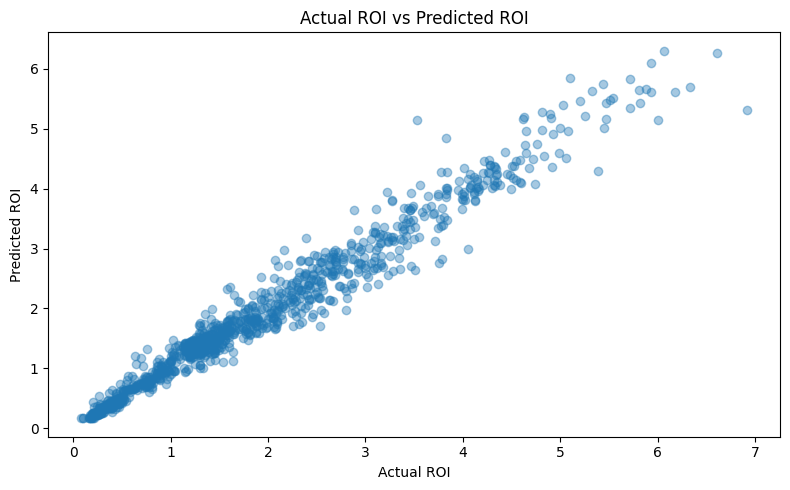

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(pred_result["actual_roi"], pred_result["predicted_roi"], alpha=0.4)
plt.title("Actual ROI vs Predicted ROI")
plt.xlabel("Actual ROI")
plt.ylabel("Predicted ROI")
plt.tight_layout()
plt.savefig("../figures/roi_prediction_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importances = model.named_steps["regressor"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
18,num__conversions,0.721469
19,num__cost,0.153625
13,cat__target_audience_en_Returning Users,0.041093
0,cat__platform_en_Kwai Ads,0.021263
2,cat__platform_en_Tencent Ads,0.012339
17,num__clicks,0.011391
1,cat__platform_en_Ocean Engine,0.006507
16,num__impressions,0.005895
5,cat__channel_en_Short Video,0.005597
8,cat__creative_type_en_Live Clip,0.004665


findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not foun

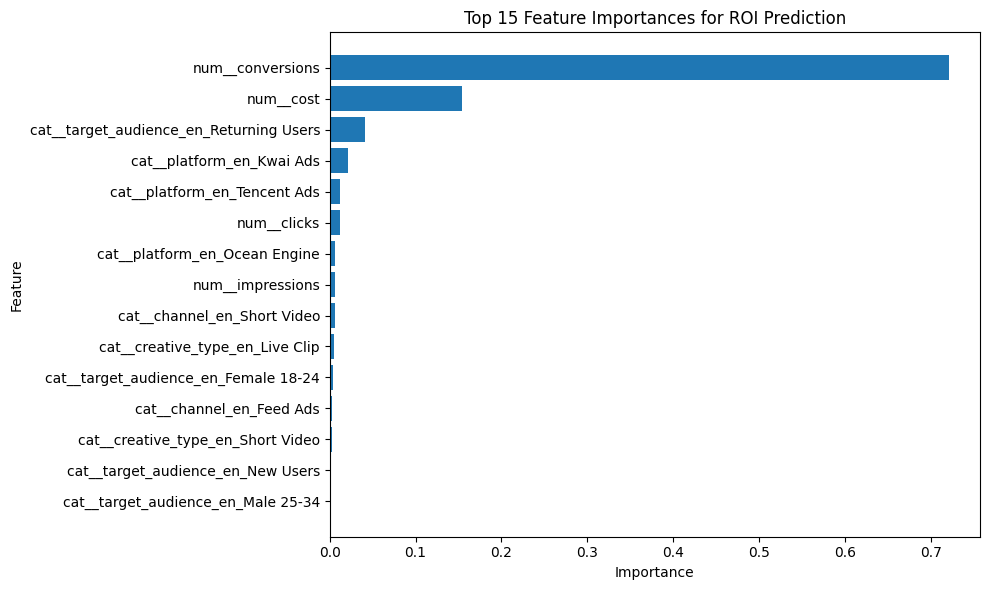

In [40]:
top_features = importance_df.head(15).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 15 Feature Importances for ROI Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../figures/roi_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## 10.Dashboard Summary

findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not foun

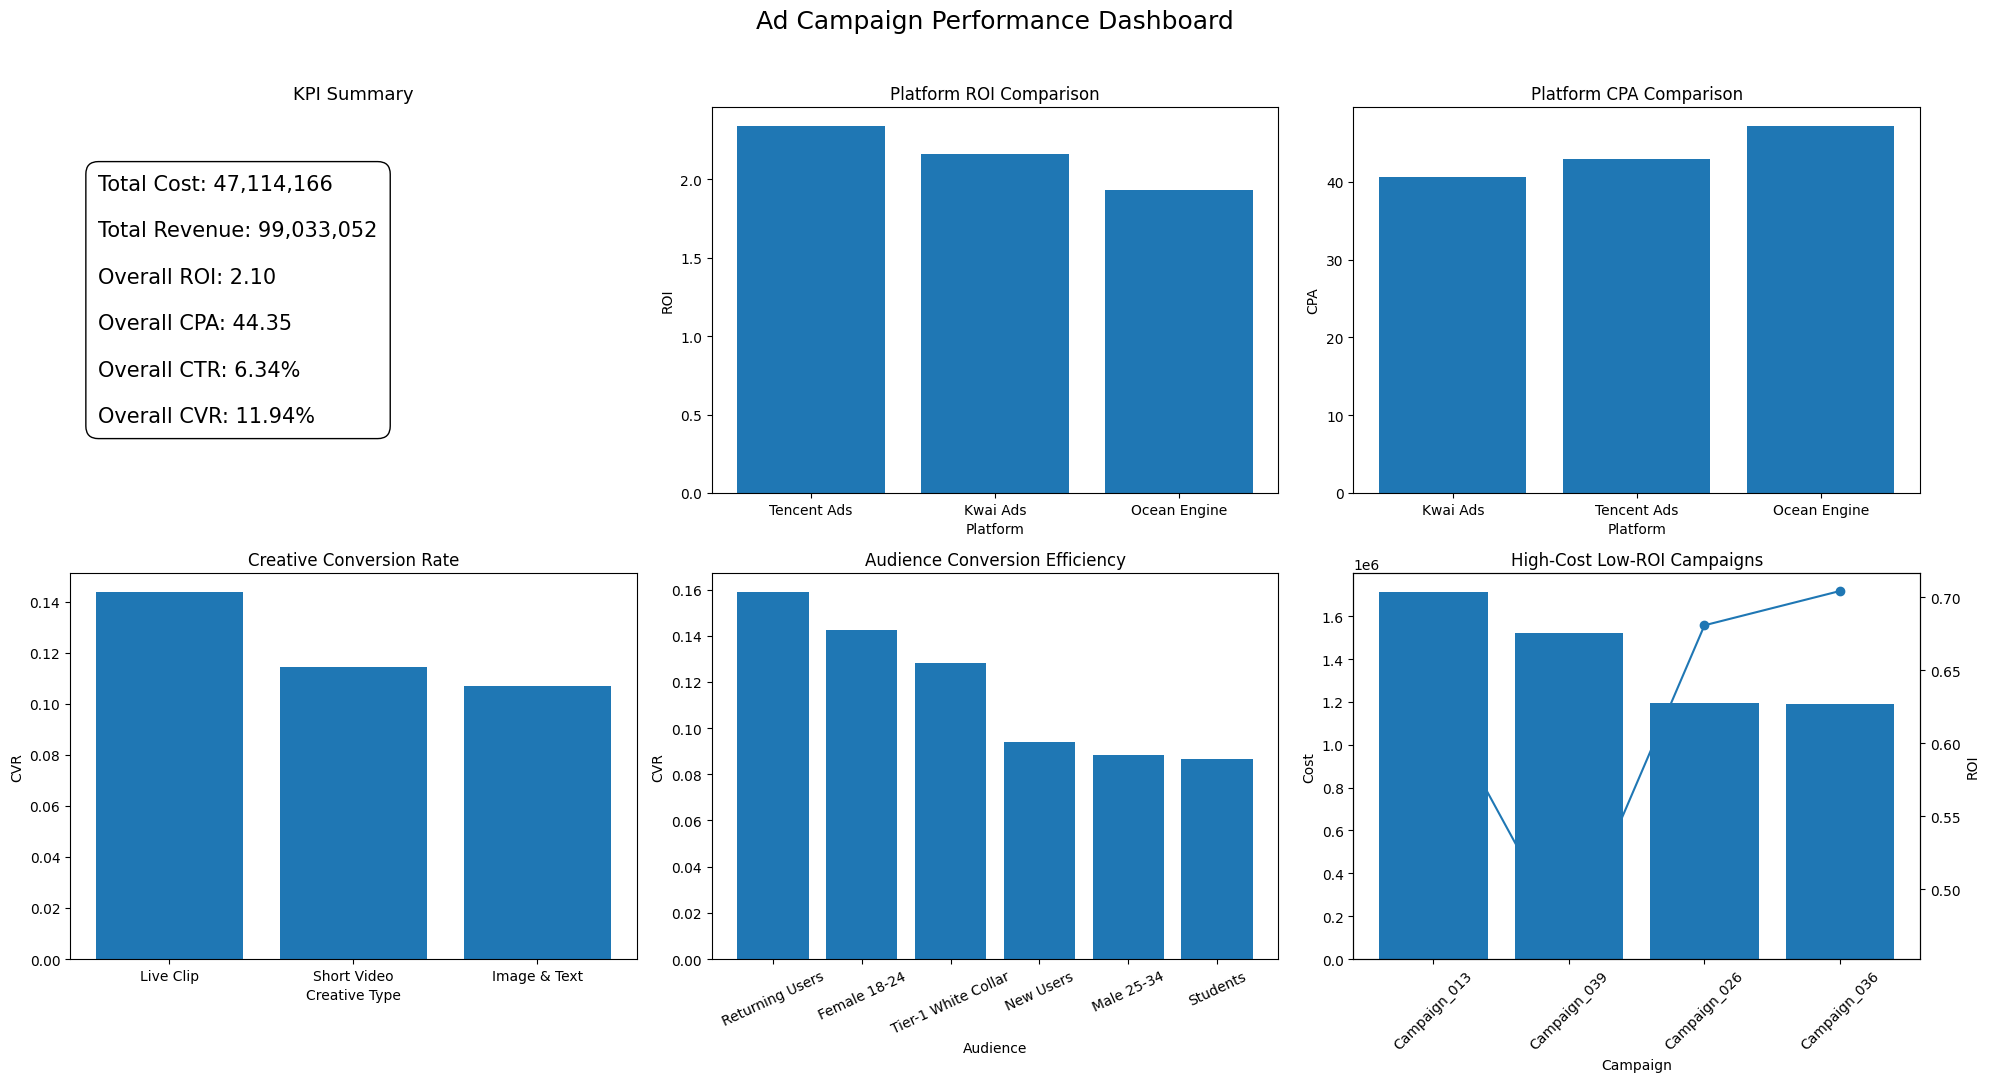

findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not foun

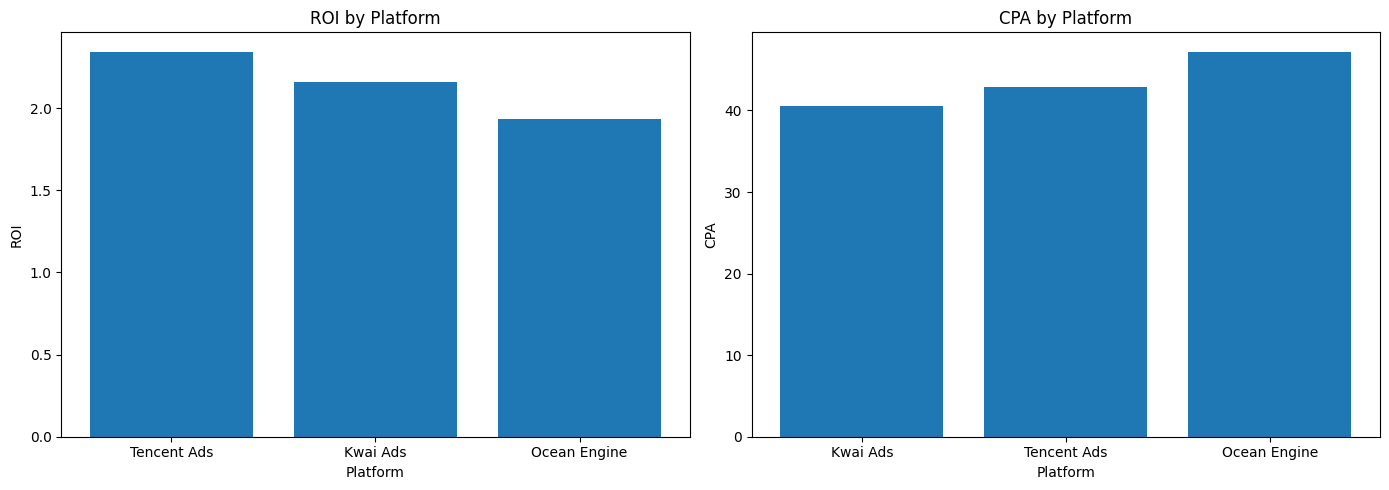

findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not foun

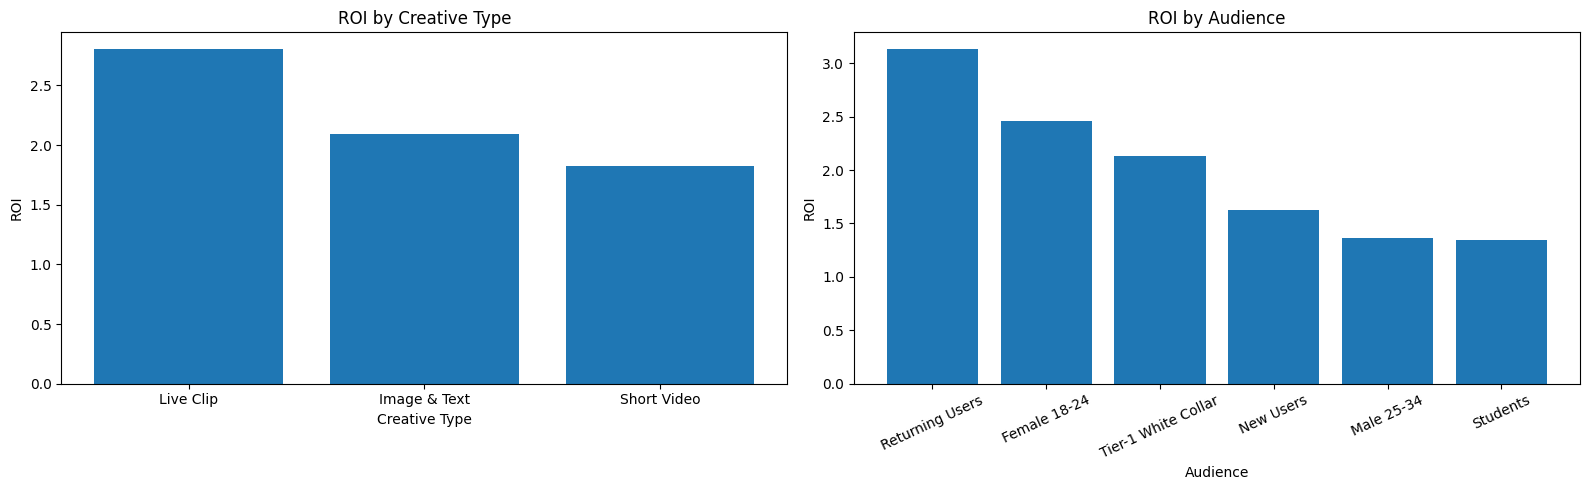

findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not foun

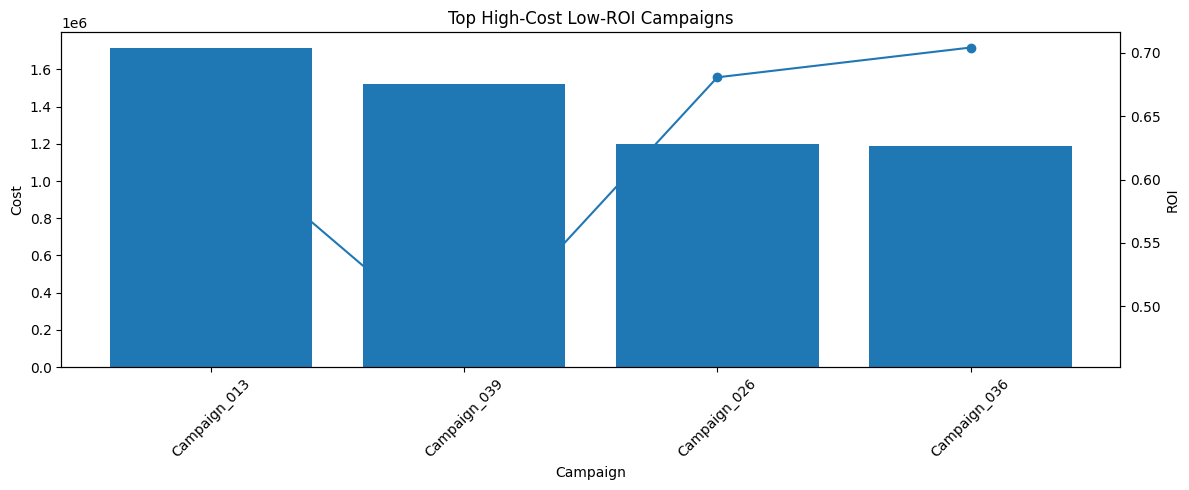

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["axes.unicode_minus"] = False

# =========================
# 1. KPI
# =========================
total_cost = df_clean["cost"].sum()
total_revenue = df_clean["revenue"].sum()
total_impressions = df_clean["impressions"].sum()
total_clicks = df_clean["clicks"].sum()
total_conversions = df_clean["conversions"].sum()

overall_ctr = total_clicks / total_impressions if total_impressions != 0 else np.nan
overall_cvr = total_conversions / total_clicks if total_clicks != 0 else np.nan
overall_cpc = total_cost / total_clicks if total_clicks != 0 else np.nan
overall_cpa = total_cost / total_conversions if total_conversions != 0 else np.nan
overall_roi = total_revenue / total_cost if total_cost != 0 else np.nan

# =========================
# 2. Platform Summary
# =========================
platform_summary = df_clean.groupby("platform_en").agg(
    impressions=("impressions", "sum"),
    clicks=("clicks", "sum"),
    conversions=("conversions", "sum"),
    cost=("cost", "sum"),
    revenue=("revenue", "sum")
).reset_index()

platform_summary["ctr"] = platform_summary["clicks"] / platform_summary["impressions"]
platform_summary["cvr"] = platform_summary["conversions"] / platform_summary["clicks"]
platform_summary["cpc"] = platform_summary["cost"] / platform_summary["clicks"]
platform_summary["cpa"] = platform_summary["cost"] / platform_summary["conversions"]
platform_summary["roi"] = platform_summary["revenue"] / platform_summary["cost"]

platform_summary = platform_summary.replace([np.inf, -np.inf], np.nan)

platform_roi_sorted = platform_summary.sort_values(by="roi", ascending=False)
platform_cpa_sorted = platform_summary.sort_values(by="cpa", ascending=True)

# =========================
# 3. Creative Summary
# =========================
creative_summary = df_clean.groupby("creative_type_en").agg(
    impressions=("impressions", "sum"),
    clicks=("clicks", "sum"),
    conversions=("conversions", "sum"),
    cost=("cost", "sum"),
    revenue=("revenue", "sum")
).reset_index()

creative_summary["ctr"] = creative_summary["clicks"] / creative_summary["impressions"]
creative_summary["cvr"] = creative_summary["conversions"] / creative_summary["clicks"]
creative_summary["cpc"] = creative_summary["cost"] / creative_summary["clicks"]
creative_summary["cpa"] = creative_summary["cost"] / creative_summary["conversions"]
creative_summary["roi"] = creative_summary["revenue"] / creative_summary["cost"]

creative_summary = creative_summary.replace([np.inf, -np.inf], np.nan)
creative_cvr_sorted = creative_summary.sort_values(by="cvr", ascending=False)
creative_roi_sorted = creative_summary.sort_values(by="roi", ascending=False)

# =========================
# 4. Audience Summary
# =========================
audience_summary = df_clean.groupby("target_audience_en").agg(
    impressions=("impressions", "sum"),
    clicks=("clicks", "sum"),
    conversions=("conversions", "sum"),
    cost=("cost", "sum"),
    revenue=("revenue", "sum")
).reset_index()

audience_summary["ctr"] = audience_summary["clicks"] / audience_summary["impressions"]
audience_summary["cvr"] = audience_summary["conversions"] / audience_summary["clicks"]
audience_summary["cpc"] = audience_summary["cost"] / audience_summary["clicks"]
audience_summary["cpa"] = audience_summary["cost"] / audience_summary["conversions"]
audience_summary["roi"] = audience_summary["revenue"] / audience_summary["cost"]

audience_summary = audience_summary.replace([np.inf, -np.inf], np.nan)
audience_cvr_sorted = audience_summary.sort_values(by="cvr", ascending=False)
audience_roi_sorted = audience_summary.sort_values(by="roi", ascending=False)

# =========================
# 5. Problem Campaigns
# =========================
campaign_summary = df_clean.groupby("campaign_name").agg(
    impressions=("impressions", "sum"),
    clicks=("clicks", "sum"),
    conversions=("conversions", "sum"),
    cost=("cost", "sum"),
    revenue=("revenue", "sum")
).reset_index()

campaign_summary["ctr"] = campaign_summary["clicks"] / campaign_summary["impressions"]
campaign_summary["cvr"] = campaign_summary["conversions"] / campaign_summary["clicks"]
campaign_summary["cpc"] = campaign_summary["cost"] / campaign_summary["clicks"]
campaign_summary["cpa"] = campaign_summary["cost"] / campaign_summary["conversions"]
campaign_summary["roi"] = campaign_summary["revenue"] / campaign_summary["cost"]

campaign_summary = campaign_summary.replace([np.inf, -np.inf], np.nan)

cost_threshold = campaign_summary["cost"].quantile(0.75)
roi_threshold = campaign_summary["roi"].quantile(0.25)

problem_campaigns = campaign_summary[
    (campaign_summary["cost"] >= cost_threshold) &
    (campaign_summary["roi"] <= roi_threshold)
].copy().sort_values(by="cost", ascending=False)

problem_campaigns["campaign_label"] = (
    problem_campaigns["campaign_name"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
)

problem_campaigns["campaign_label"] = problem_campaigns["campaign_label"].fillna(problem_campaigns["campaign_name"])
problem_campaigns["campaign_label"] = problem_campaigns["campaign_label"].apply(
    lambda x: f"Campaign_{int(x):03d}" if str(x).isdigit() else str(x)
)

top_problem_campaigns = problem_campaigns.head(10)

# =========================
# 6. Dashboard Summary
# =========================
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle("Ad Campaign Performance Dashboard", fontsize=18, y=0.98)

# (1) KPI Summary
axes[0, 0].axis("off")
kpi_text = (
    f"Total Cost: {total_cost:,.0f}\n\n"
    f"Total Revenue: {total_revenue:,.0f}\n\n"
    f"Overall ROI: {overall_roi:.2f}\n\n"
    f"Overall CPA: {overall_cpa:.2f}\n\n"
    f"Overall CTR: {overall_ctr:.2%}\n\n"
    f"Overall CVR: {overall_cvr:.2%}"
)
axes[0, 0].text(
    0.05, 0.5, kpi_text,
    fontsize=15, va="center", ha="left",
    bbox=dict(boxstyle="round,pad=0.6", edgecolor="black", facecolor="white")
)
axes[0, 0].set_title("KPI Summary", fontsize=13)

# (2) ROI by Platform
axes[0, 1].bar(platform_roi_sorted["platform_en"], platform_roi_sorted["roi"])
axes[0, 1].set_title("Platform ROI Comparison")
axes[0, 1].set_xlabel("Platform")
axes[0, 1].set_ylabel("ROI")

# (3) CPA by Platform
axes[0, 2].bar(platform_cpa_sorted["platform_en"], platform_cpa_sorted["cpa"])
axes[0, 2].set_title("Platform CPA Comparison")
axes[0, 2].set_xlabel("Platform")
axes[0, 2].set_ylabel("CPA")

# (4) CVR by Creative Type
axes[1, 0].bar(creative_cvr_sorted["creative_type_en"], creative_cvr_sorted["cvr"])
axes[1, 0].set_title("Creative Conversion Rate")
axes[1, 0].set_xlabel("Creative Type")
axes[1, 0].set_ylabel("CVR")

# (5) CVR by Audience
axes[1, 1].bar(audience_cvr_sorted["target_audience_en"], audience_cvr_sorted["cvr"])
axes[1, 1].set_title("Audience Conversion Efficiency")
axes[1, 1].set_xlabel("Audience")
axes[1, 1].set_ylabel("CVR")
axes[1, 1].tick_params(axis="x", rotation=25)

# (6) High-Cost Low-ROI Campaigns (dual axis)
ax_bar = axes[1, 2]
ax_line = ax_bar.twinx()

ax_bar.bar(top_problem_campaigns["campaign_label"], top_problem_campaigns["cost"])
ax_bar.set_title("High-Cost Low-ROI Campaigns")
ax_bar.set_xlabel("Campaign")
ax_bar.set_ylabel("Cost")
ax_bar.tick_params(axis="x", rotation=45)

ax_line.plot(
    top_problem_campaigns["campaign_label"],
    top_problem_campaigns["roi"],
    marker="o"
)
ax_line.set_ylabel("ROI")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("../figures/dashboard_summary.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 7. Extra Figure 1: Platform Performance
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(platform_roi_sorted["platform_en"], platform_roi_sorted["roi"])
axes[0].set_title("ROI by Platform")
axes[0].set_xlabel("Platform")
axes[0].set_ylabel("ROI")

axes[1].bar(platform_cpa_sorted["platform_en"], platform_cpa_sorted["cpa"])
axes[1].set_title("CPA by Platform")
axes[1].set_xlabel("Platform")
axes[1].set_ylabel("CPA")

plt.tight_layout()
plt.savefig("../figures/platform_performance.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 8. Extra Figure 2: Creative & Audience Analysis
# =========================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(creative_roi_sorted["creative_type_en"], creative_roi_sorted["roi"])
axes[0].set_title("ROI by Creative Type")
axes[0].set_xlabel("Creative Type")
axes[0].set_ylabel("ROI")

axes[1].bar(audience_roi_sorted["target_audience_en"], audience_roi_sorted["roi"])
axes[1].set_title("ROI by Audience")
axes[1].set_xlabel("Audience")
axes[1].set_ylabel("ROI")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig("../figures/creative_audience_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 9. Extra Figure 3: Problem Campaigns
# =========================
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(top_problem_campaigns["campaign_label"], top_problem_campaigns["cost"])
ax1.set_xlabel("Campaign")
ax1.set_ylabel("Cost")
ax1.set_title("Top High-Cost Low-ROI Campaigns")
ax1.tick_params(axis="x", rotation=45)

ax2.plot(
    top_problem_campaigns["campaign_label"],
    top_problem_campaigns["roi"],
    marker="o"
)
ax2.set_ylabel("ROI")

plt.tight_layout()
plt.savefig("../figures/problem_campaigns.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
platform_summary.to_csv("../data/clean/platform_summary.csv", index=False)
creative_summary.to_csv("../data/clean/creative_summary.csv", index=False)
audience_summary.to_csv("../data/cblem_campaigns.to_csv("../data/clean/problem_campaigns.csv", index=False)